<a href="https://colab.research.google.com/github/Rogire/Aulas-MAC019/blob/main/MAC019_AULA15_2026_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# instalação do anastruct
!pip install anastruct

# importando os pacotes
import numpy as np
import matplotlib.pyplot as plt

from anastruct import SystemElements

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 777.7/777.7 kB 13.7 MB/s eta 0:00:00


# Vigas inclinadas

**Exemplo:** Note que, apesar do carregamento ser vertical, ao analisar o eixo da viga a decomposição do carregamento gera tanto forças perpendiculares quando normais a esse eixo.

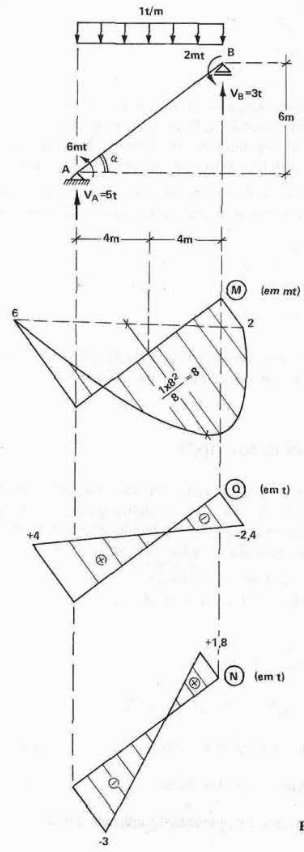

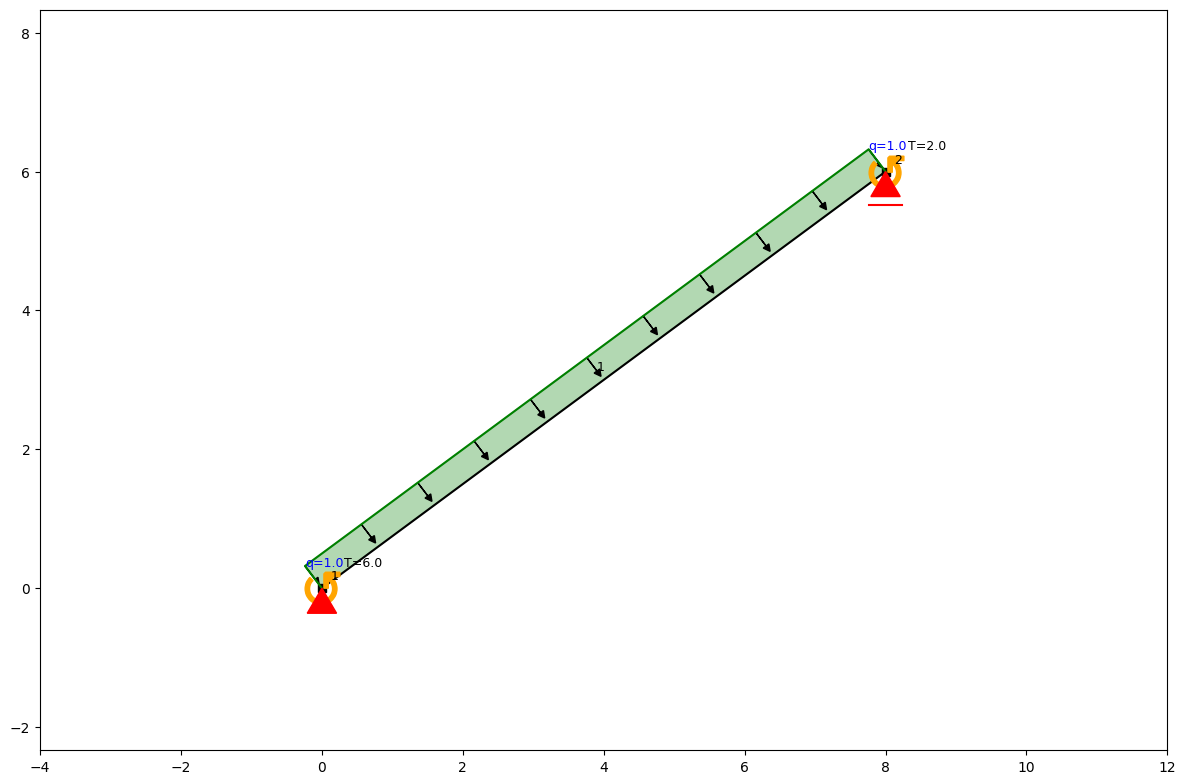

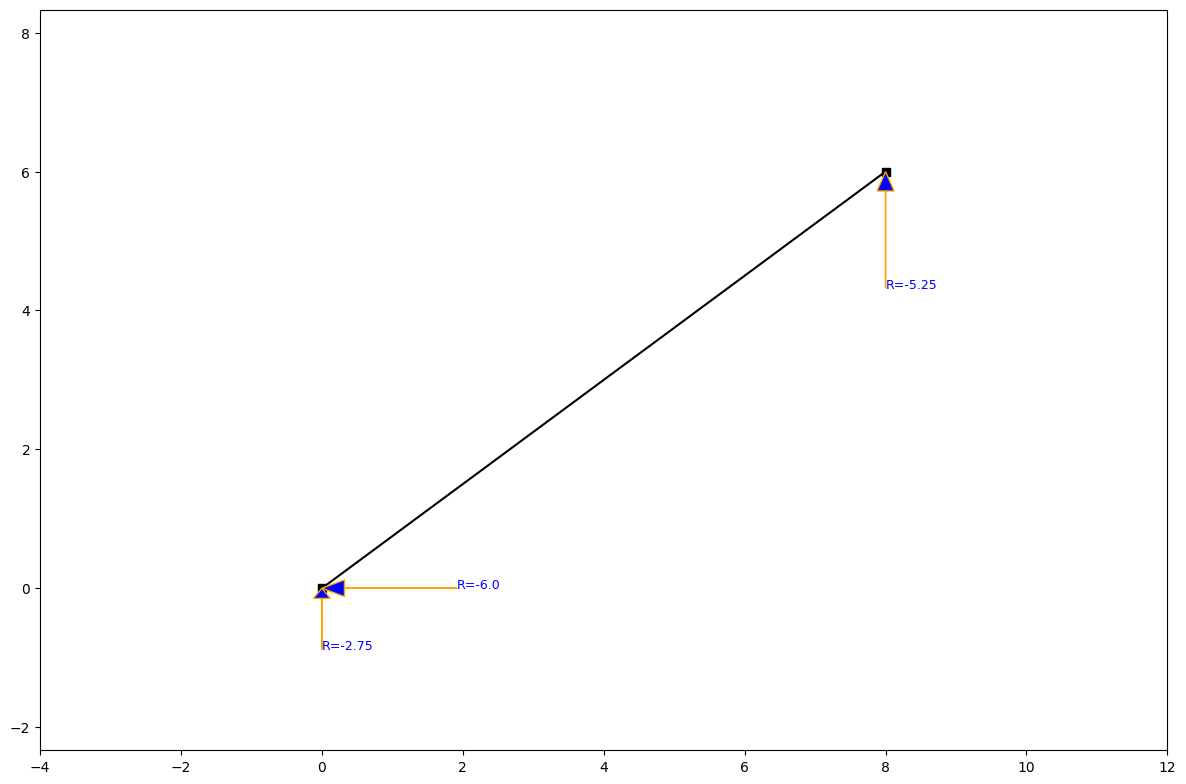

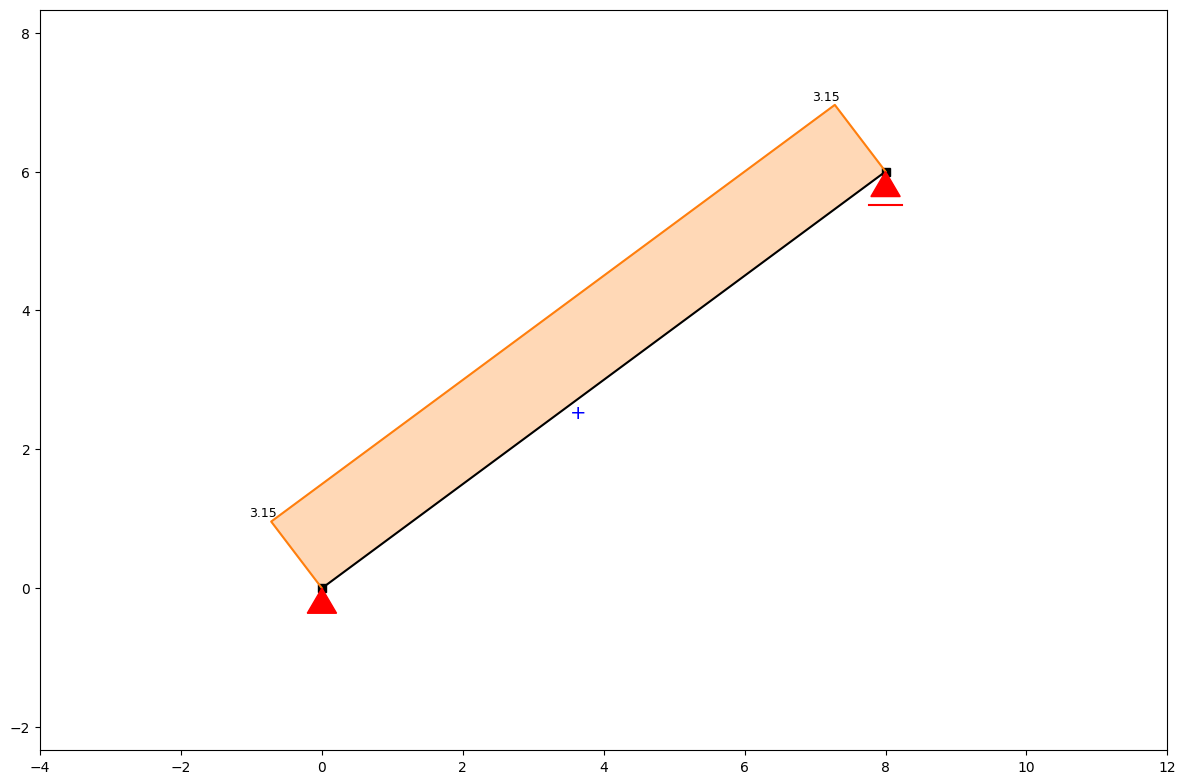

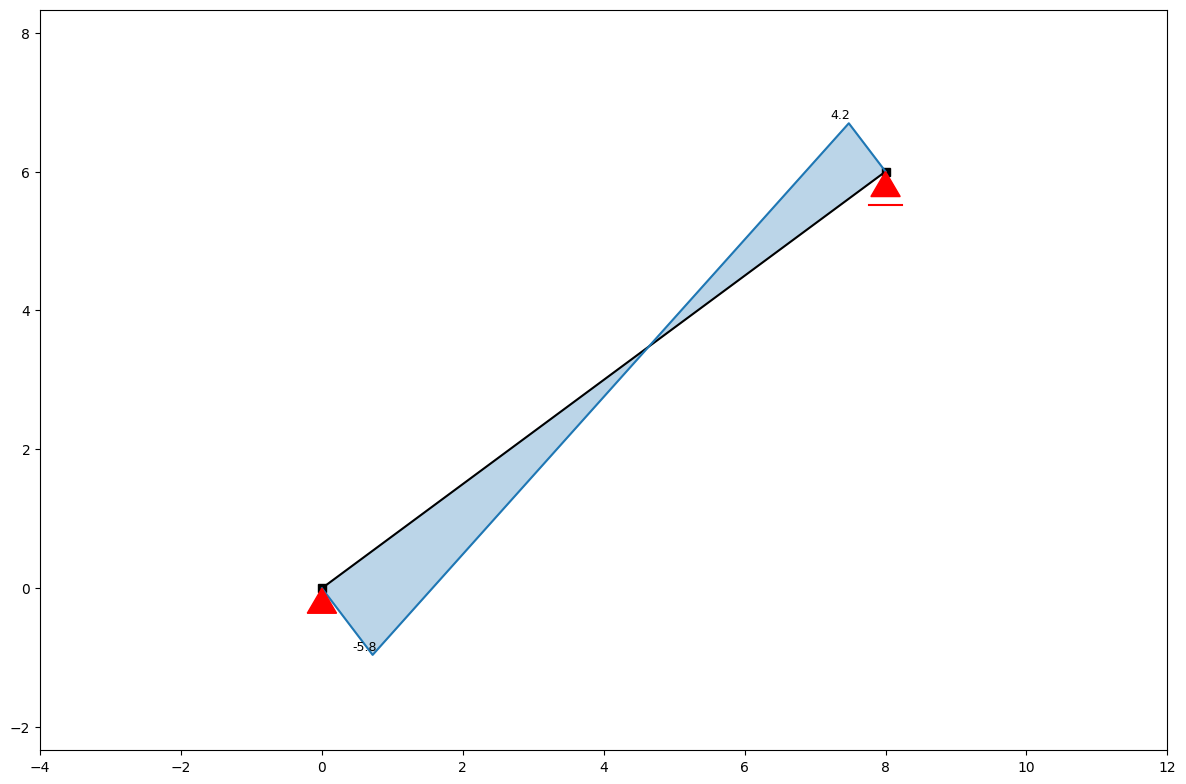

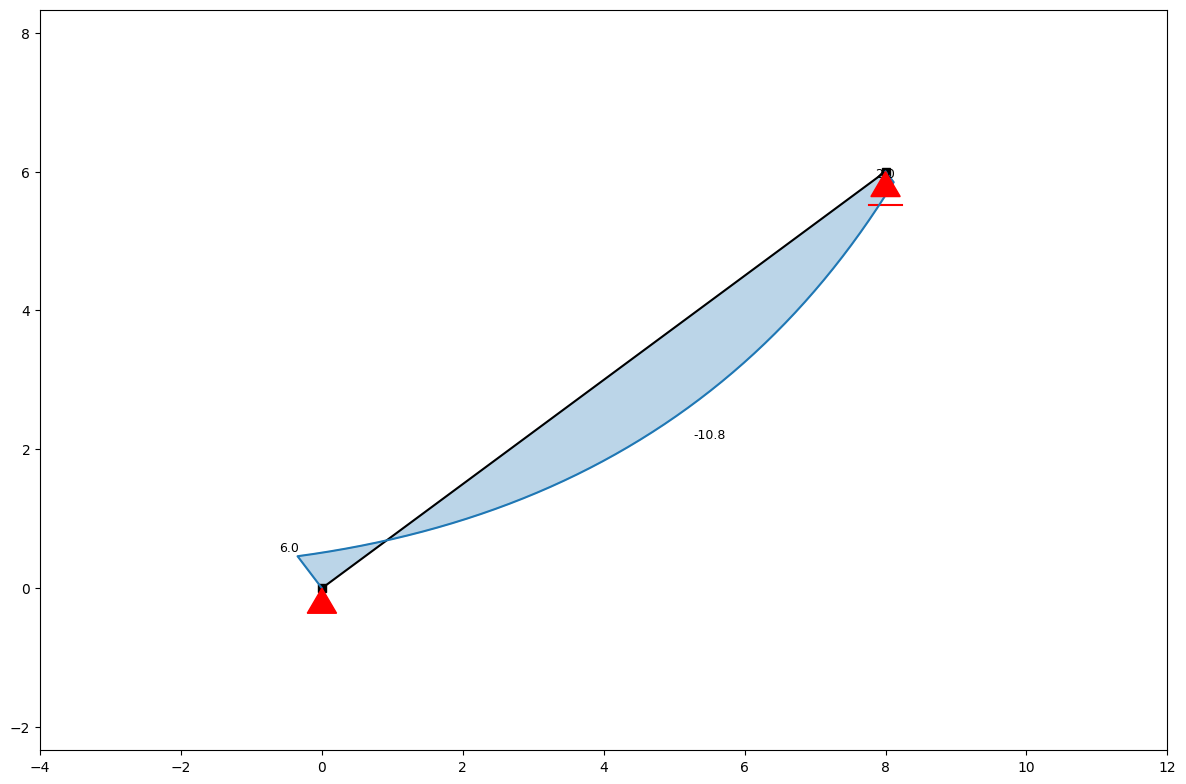

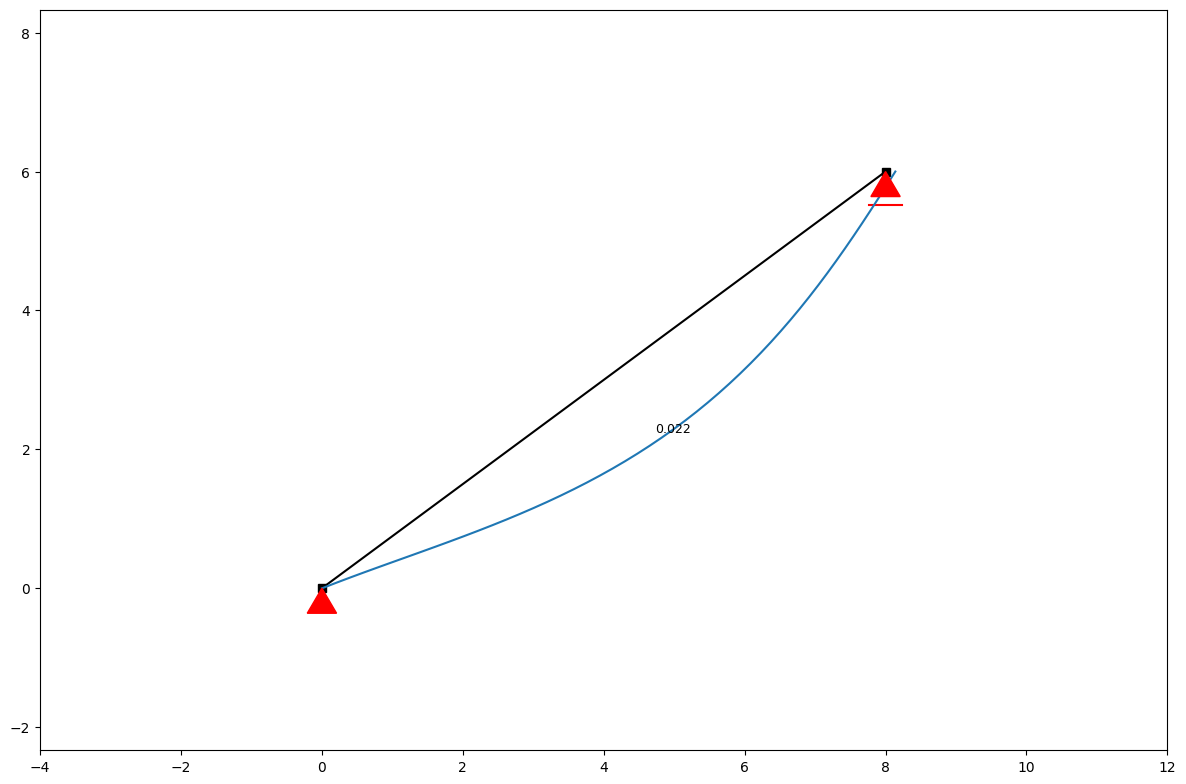

In [ ]:
# SOLUÇÃO EXEMPLO 1

ss = SystemElements()

ss.add_element(location = [[0, 0], [8, 6]])
ss.add_support_hinged(node_id=1)
ss.add_support_roll(node_id=2, direction='x')

ss.q_load(q=-1, element_id=1, direction='element')
#ss.q_load(q=-1, element_id=1, direction='y')

# L_viga = np.sqrt(8 ** 2 + 6 ** 2)
# Lx = 8
# q_real = -1
# q_corrigido = q_real * Lx / L_viga
# ss.q_load(q=q_corrigido, element_id=1, direction='y')

ss.moment_load(node_id=1, Ty=6)
ss.moment_load(node_id=2, Ty=2)

ss.show_structure()
ss.solve()
ss.show_reaction_force()
ss.show_axial_force()
ss.show_shear_force()
ss.show_bending_moment()
ss.show_displacement()

# Pórticos simples

**Exemplo 1:** O procedimento é análogo ao que vimos para vigas.

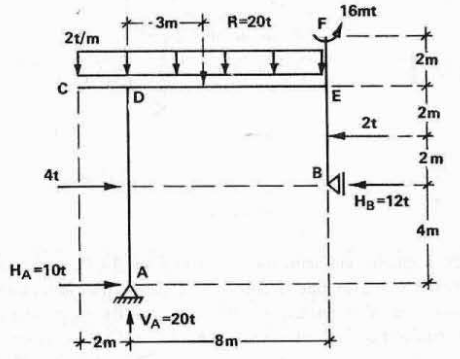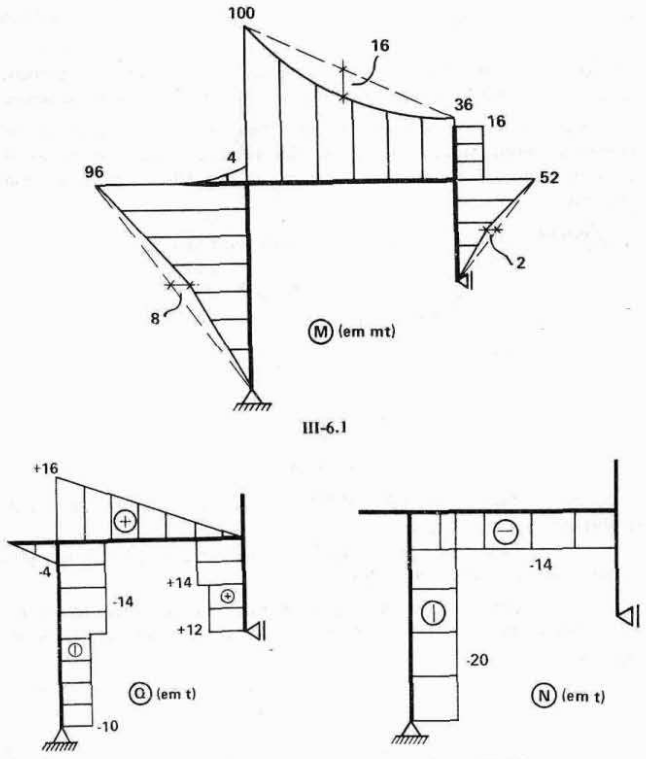

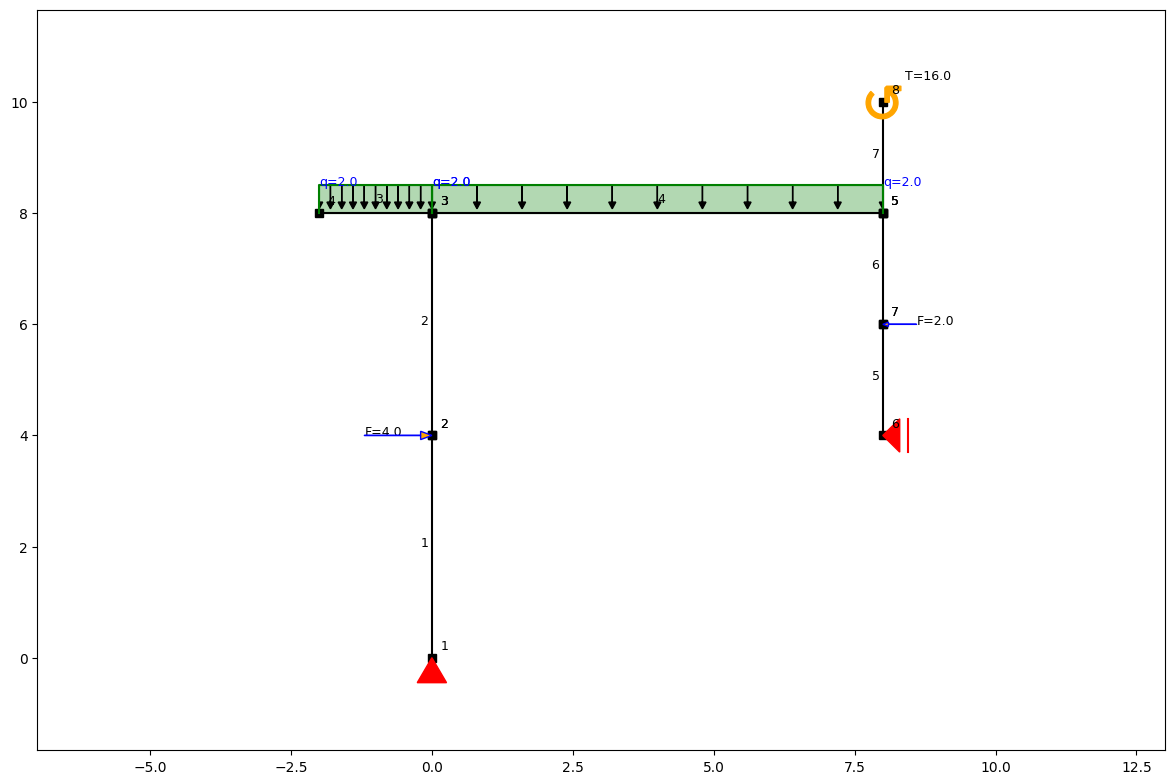

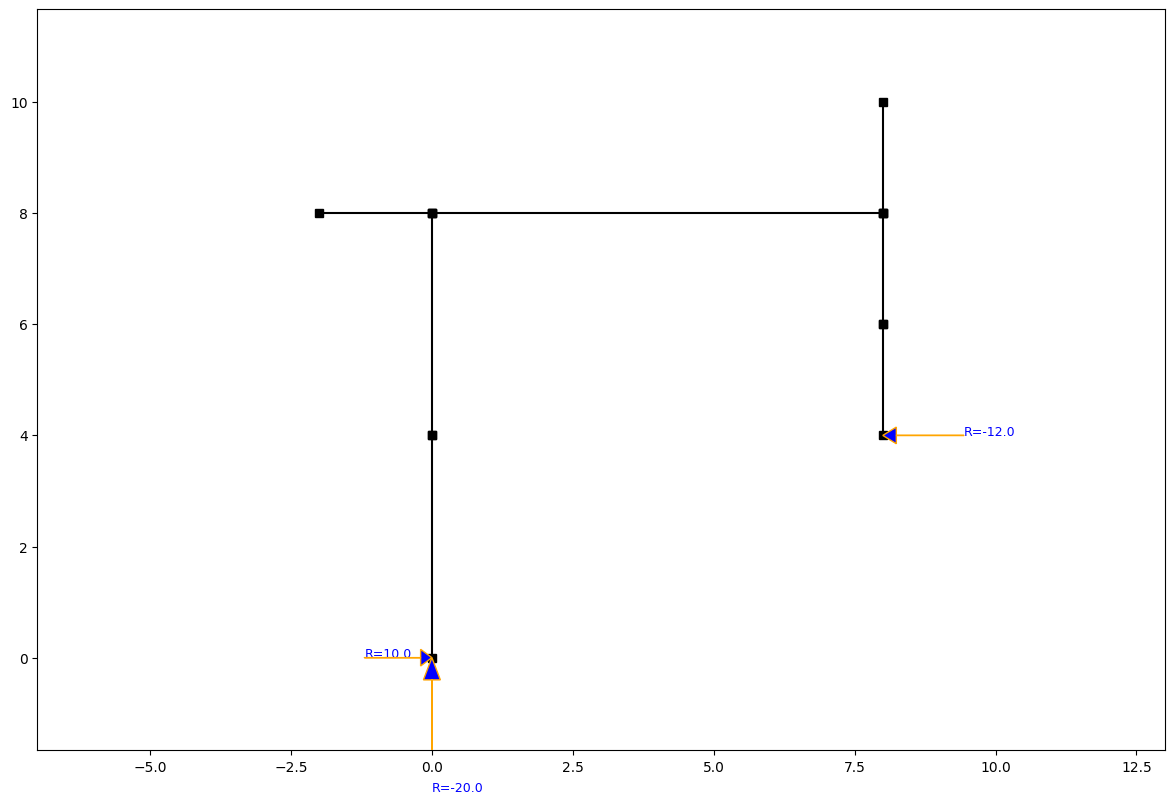

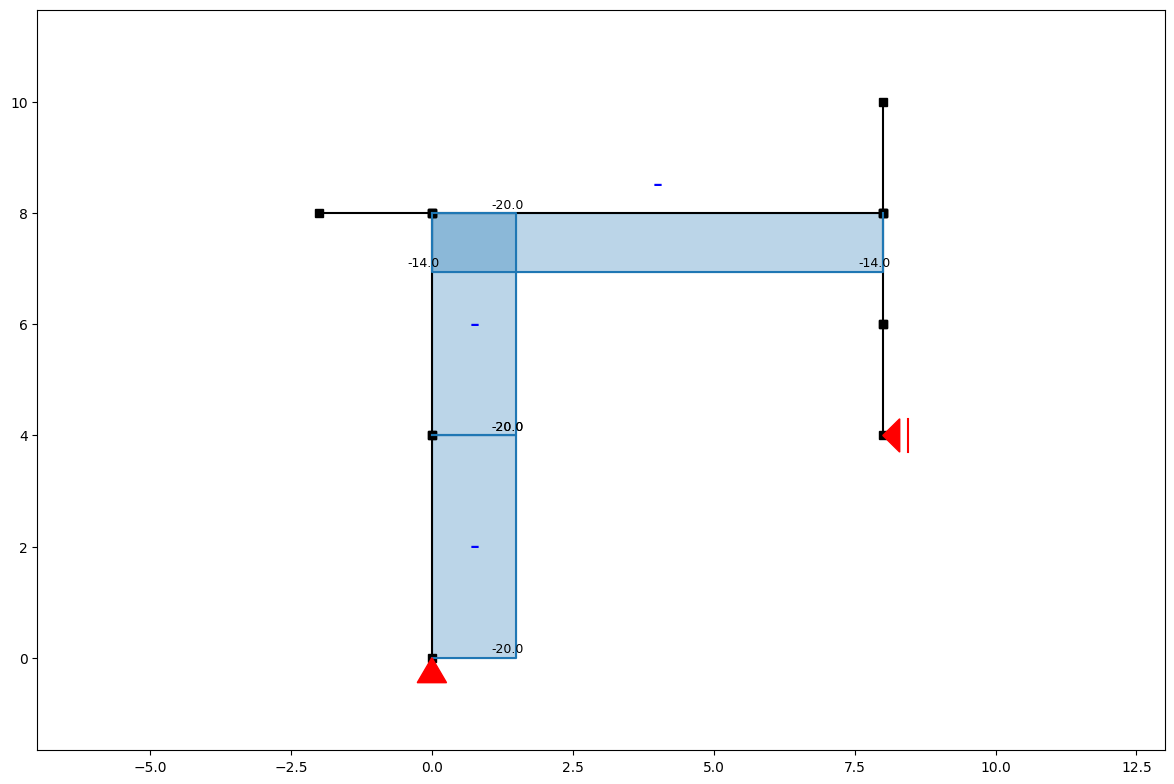

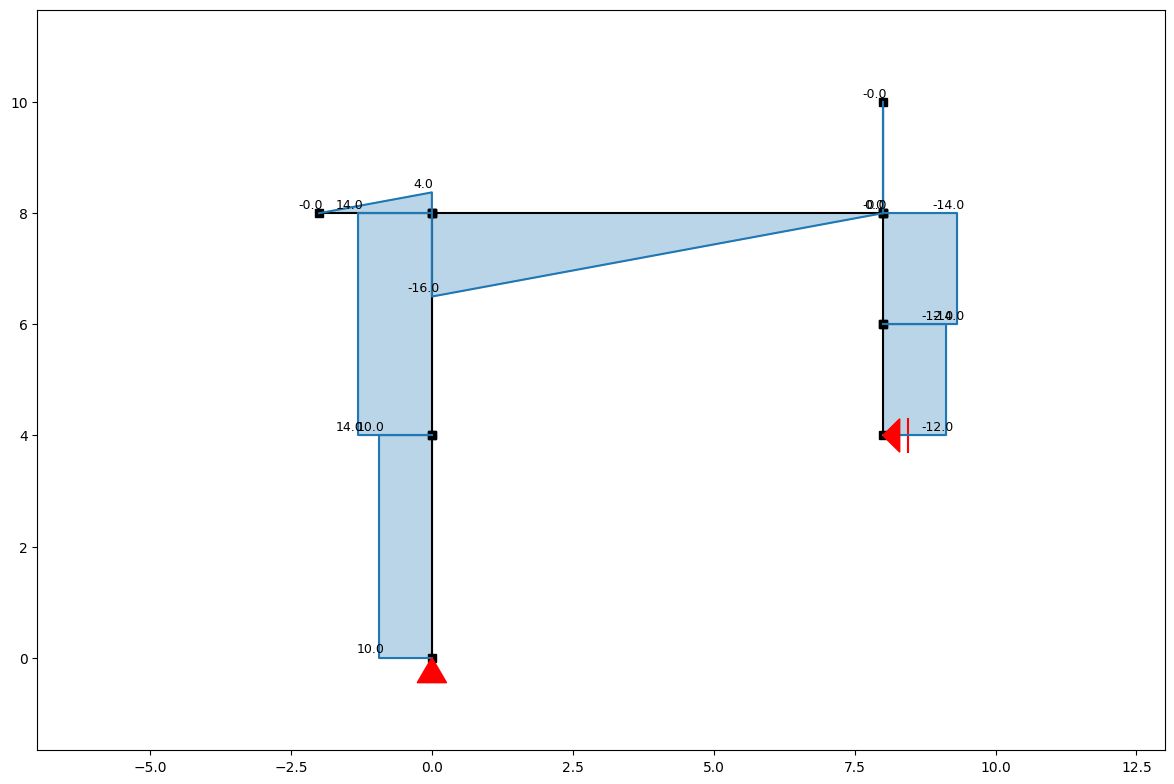

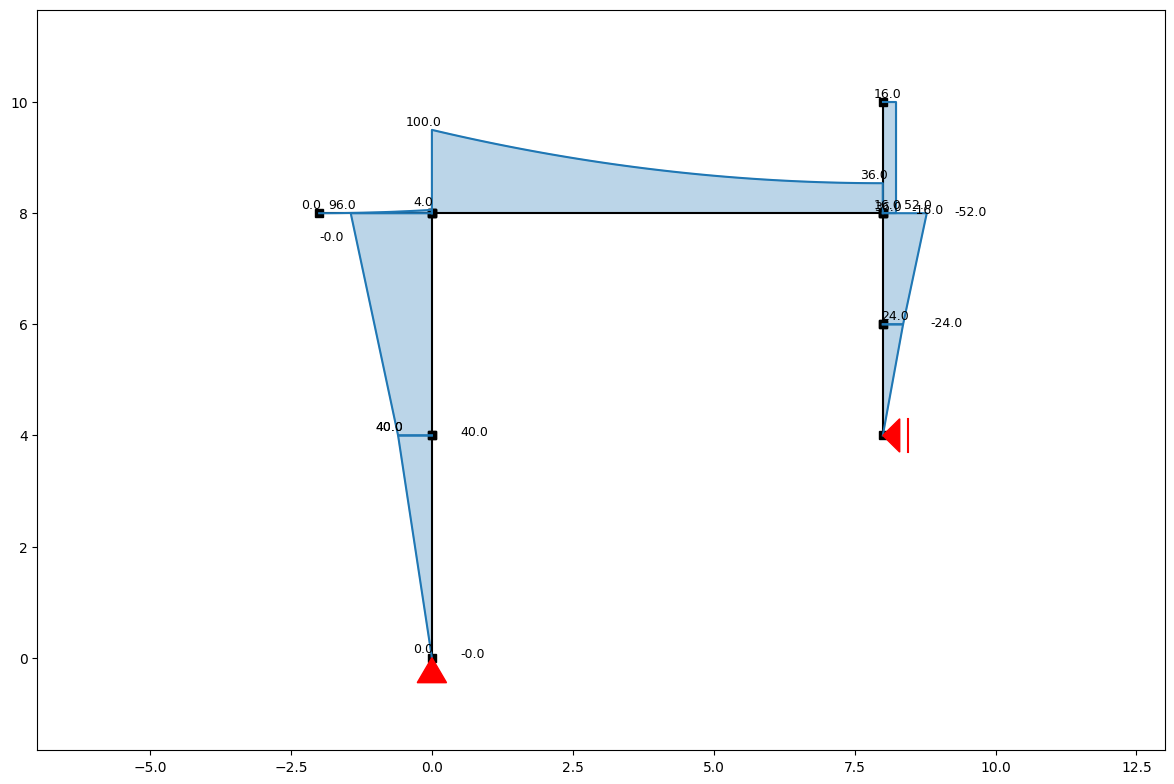

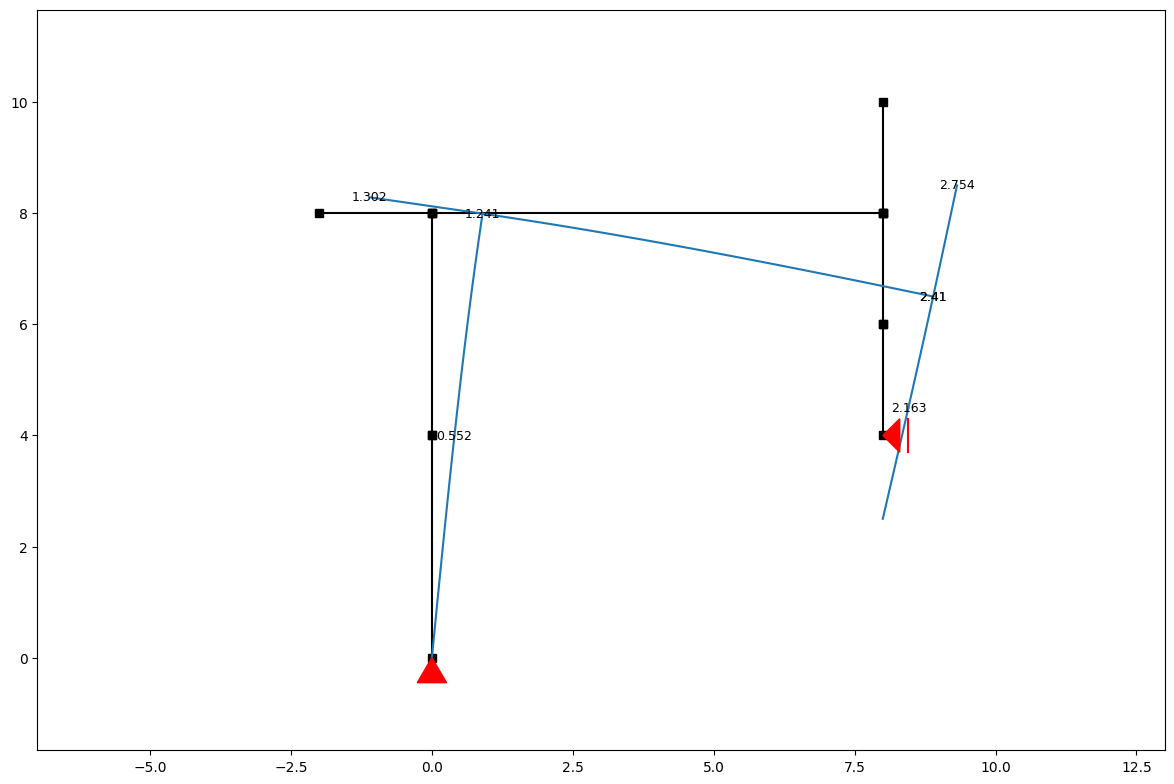

In [ ]:
# SOLUÇÃO EXEMPLO 1

ss = SystemElements()

# Elemento 1 -> AM (M é o ponto na barra AD onde tem carga)
ss.add_element(location = [[0, 0], [0, 4]])
ss.add_support_hinged(node_id=1)
ss.point_load(node_id=ss.id_last_node, Fx=4)

# Elemento 2 -> MD
ss.add_element(location = [[0, 4], [0, 8]])

# Elemento 3 -> CD
ss.add_element(location = [[-2, 8], [0, 8]])
ss.q_load(q=-2, element_id=ss.id_last_element, direction='element')

# Elemento 4 -> DE
ss.add_element(location = [[0, 8], [8, 8]])
ss.q_load(q=-2, element_id=ss.id_last_element, direction='element')

# Elemento 5 -> BN (N é o ponto em BE onde tem carga)
ss.add_element(location = [[8, 4], [8, 6]])
ss.point_load(node_id=ss.id_last_node, Fx=-2)
ss.add_support_roll(node_id=6, direction='y')

# Elemento 6 -> NE
ss.add_element(location = [[8, 6], [8, 8]])

# Elemento 7 -> EF
ss.add_element(location = [[8, 8], [8, 10]])
ss.moment_load(node_id=ss.id_last_node, Ty=16)

ss.show_structure()
ss.solve()
ss.show_reaction_force()
ss.show_axial_force()
ss.show_shear_force()
ss.show_bending_moment()
ss.show_displacement()

# Pórticos compostos

**Exemplo 2:** A resolução analítica de pórticos compostos é mais complexa, já que precisamos dividir em pórticos simples e analisaras forças que surgem nas ligações. Com o anastruct, podemos resolver facilmente.

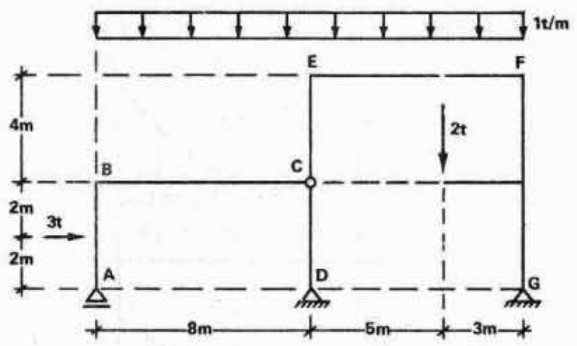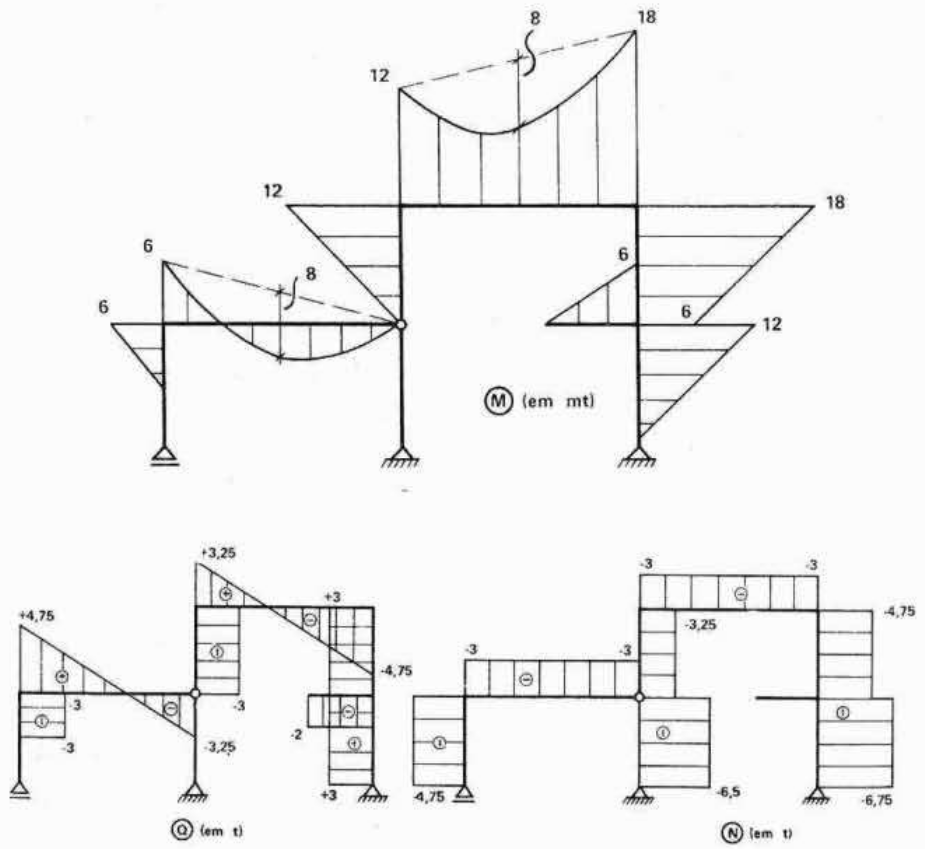

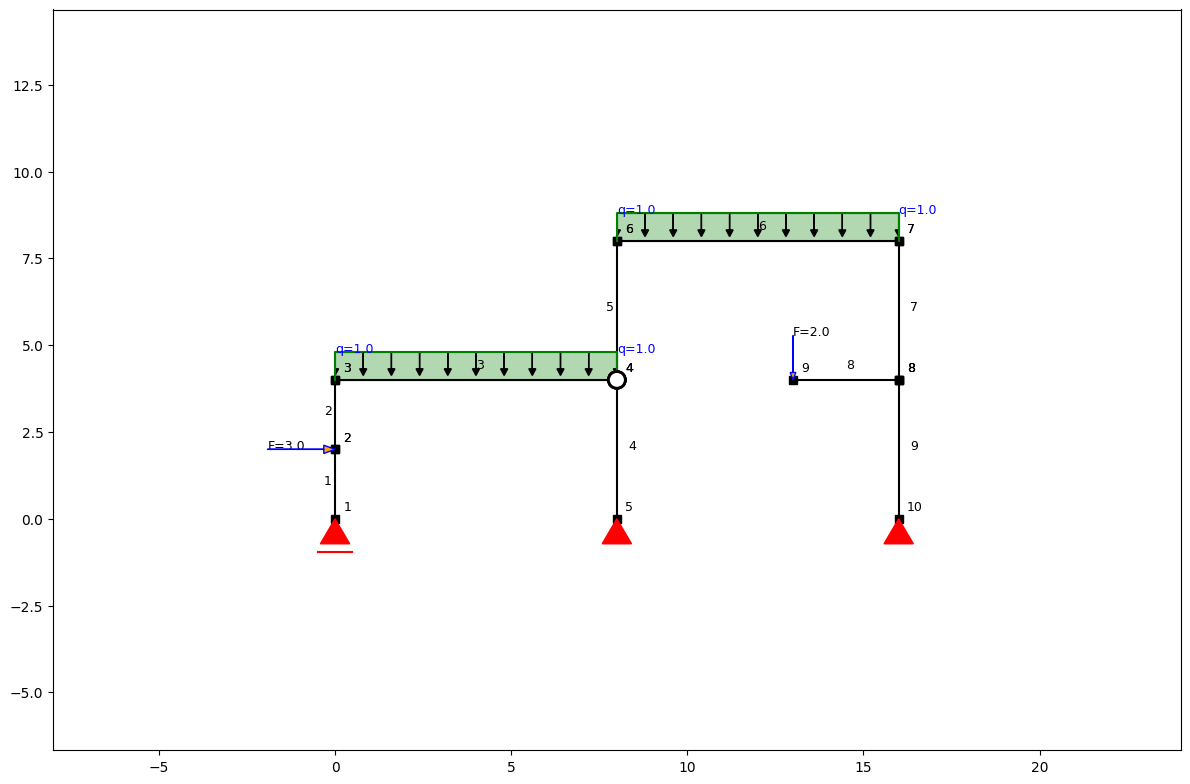

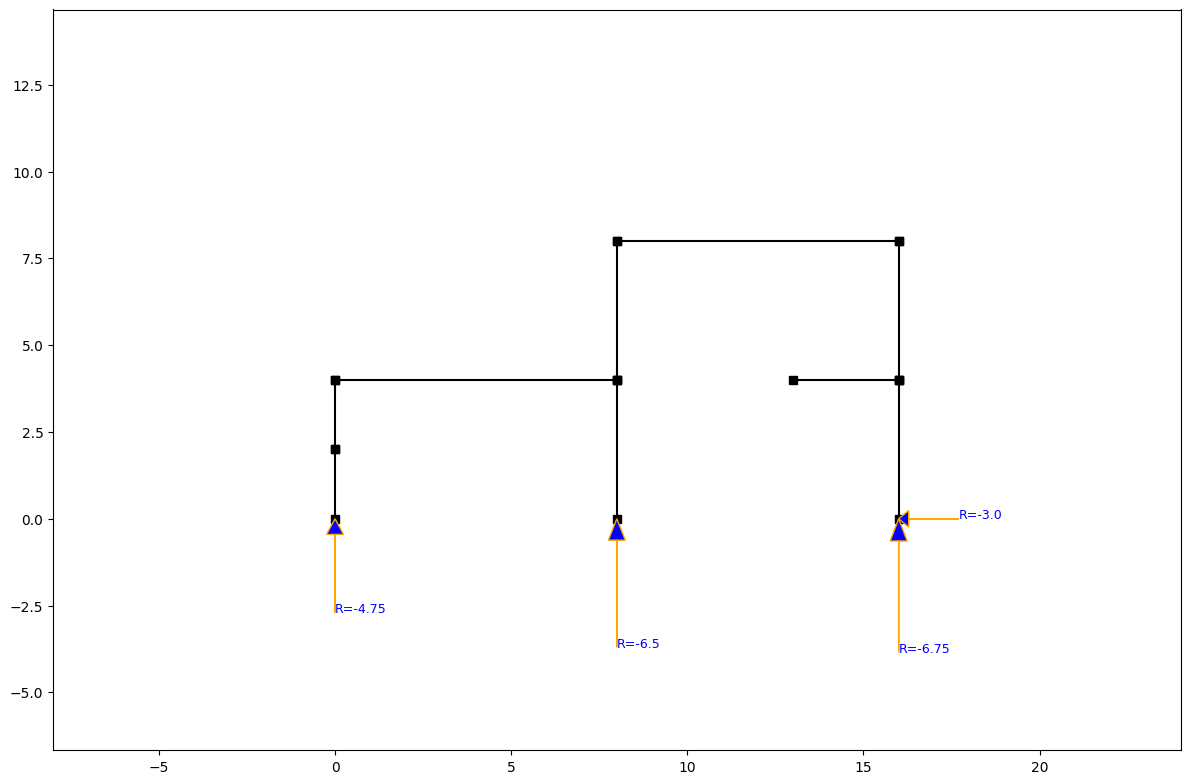

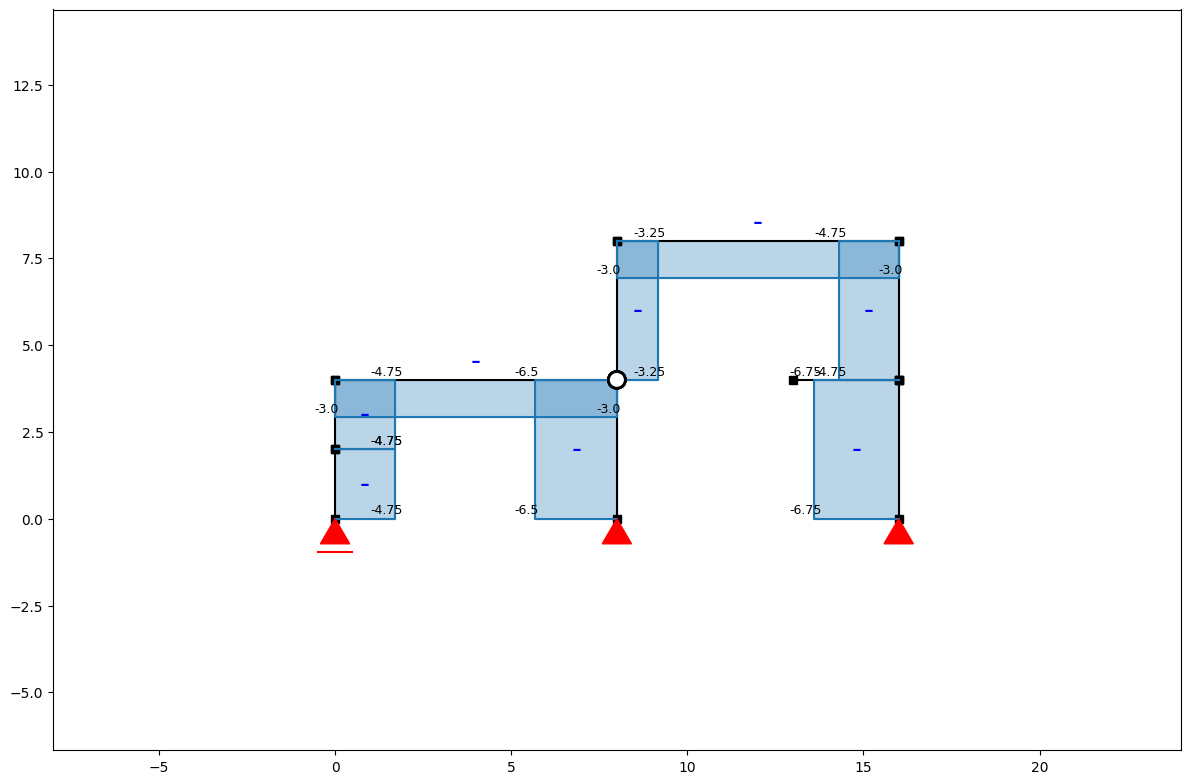

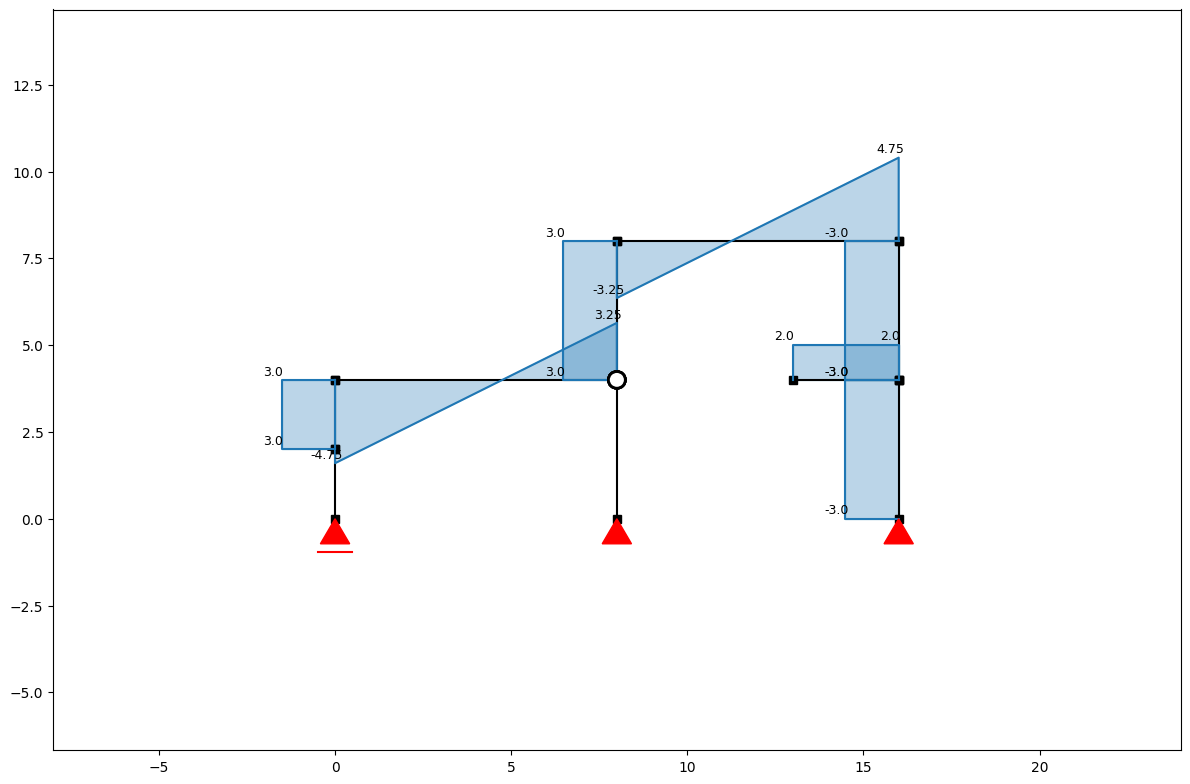

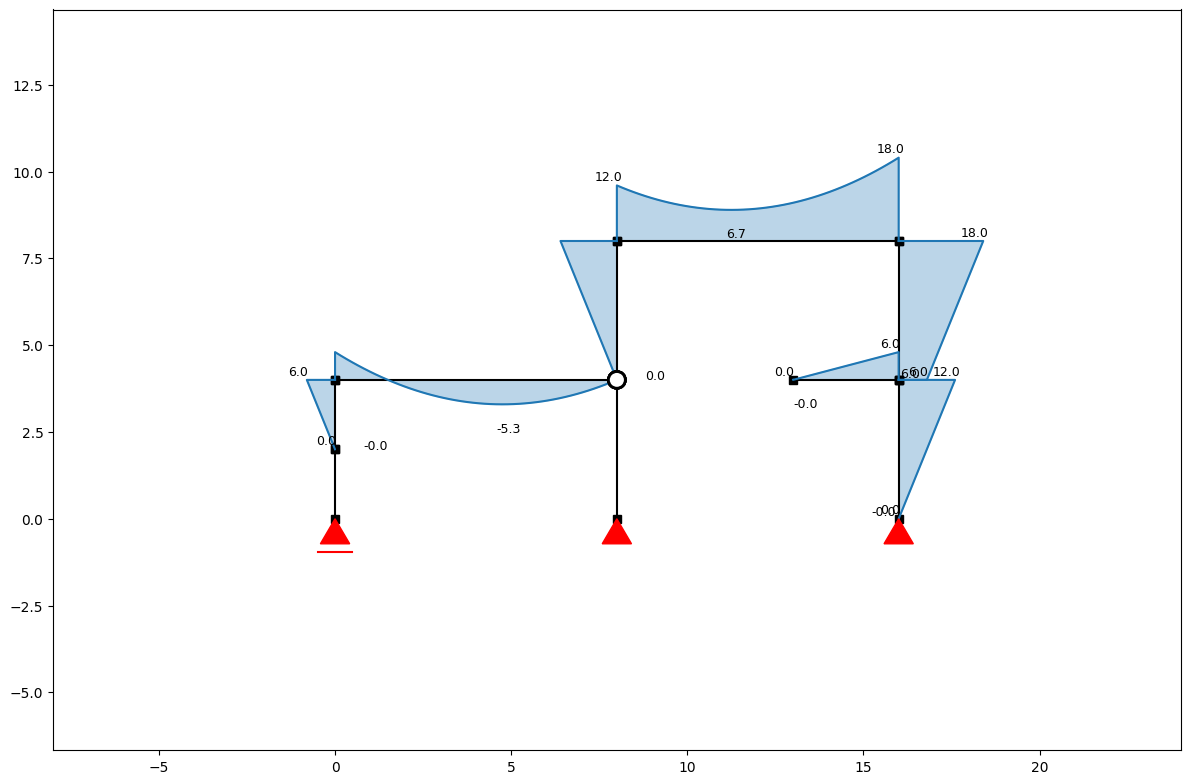

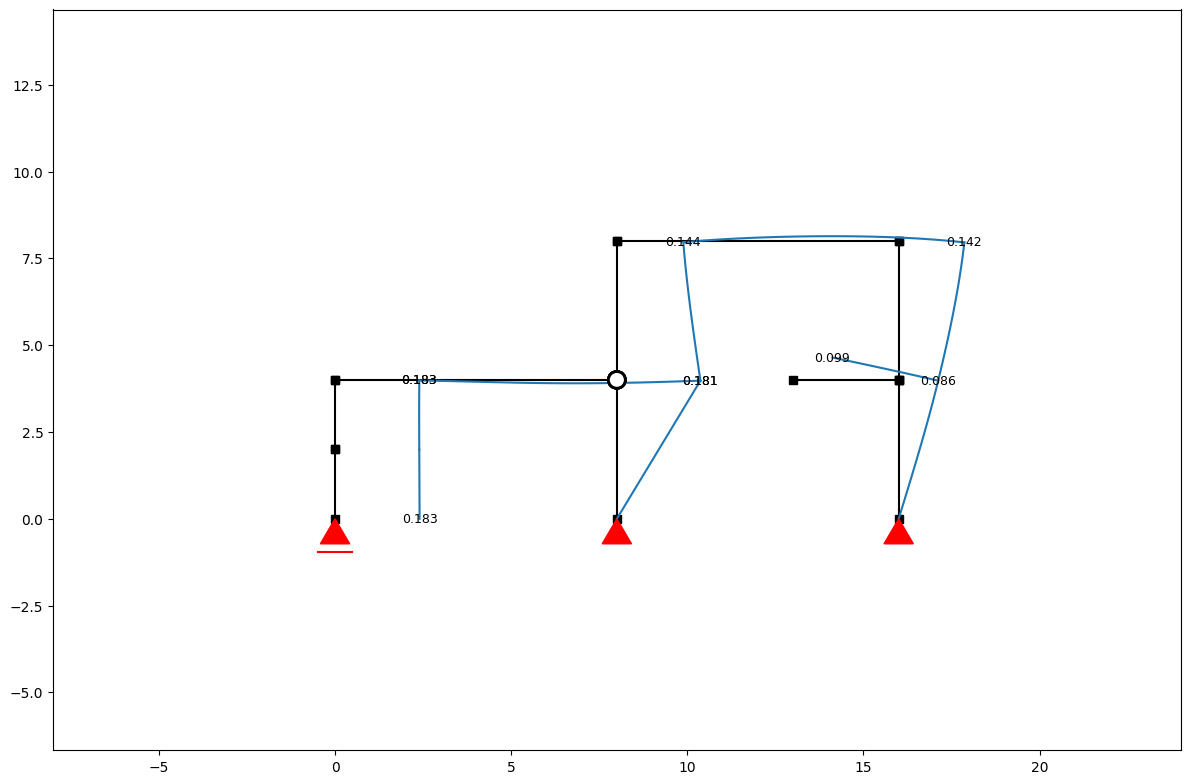

In [ ]:
# SOLUÇÃO EXEMPLO 2

ss = SystemElements()

# Elemento 1 -> AM (M é o ponto na barra AB onde tem carga)
ss.add_element(location = [[0, 0], [0, 2]])
ss.add_support_roll(node_id=1, direction='x')
ss.point_load(node_id=ss.id_last_node, Fx=3)

# Elemento 2 -> MB
ss.add_element(location = [[0, 2], [0, 4]])

# Elemento 3 -> BC
ss.add_element(location = [[0, 4], [8, 4]], spring={2:0})
ss.q_load(q=-1, element_id=ss.id_last_element, direction='element')

# Elemento 4 -> CD
ss.add_element(location = [[8, 4], [8, 0]], spring={1:0})
ss.add_support_hinged(node_id=ss.id_last_node)

# Elemento 5 -> CE
ss.add_element(location = [[8, 4], [8, 8]], spring={1:0})

# Elemento 6 -> EF
ss.add_element(location = [[8, 8], [16, 8]])
ss.q_load(q=-1, element_id=ss.id_last_element, direction='element')

# Elemento 7 -> FN (N é o ponto na barra FG onde tem carga)
ss.add_element(location = [[16, 8], [16, 4]])

# Elemento 7 -> NO
ss.add_element(location = [[16, 4], [13, 4]])
ss.point_load(node_id=ss.id_last_node, Fy=-2)

# Elemento 7 -> NG
ss.add_element(location = [[16, 4], [16, 0]])
ss.add_support_hinged(node_id=ss.id_last_node)

ss.show_structure()
ss.solve()
ss.show_reaction_force()
ss.show_axial_force()
ss.show_shear_force()
ss.show_bending_moment()
ss.show_displacement()

# Pórticos com apoio inclinado

**Exemplo 3:**

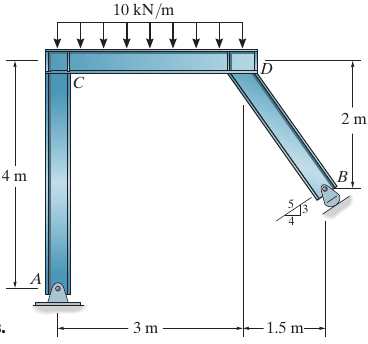

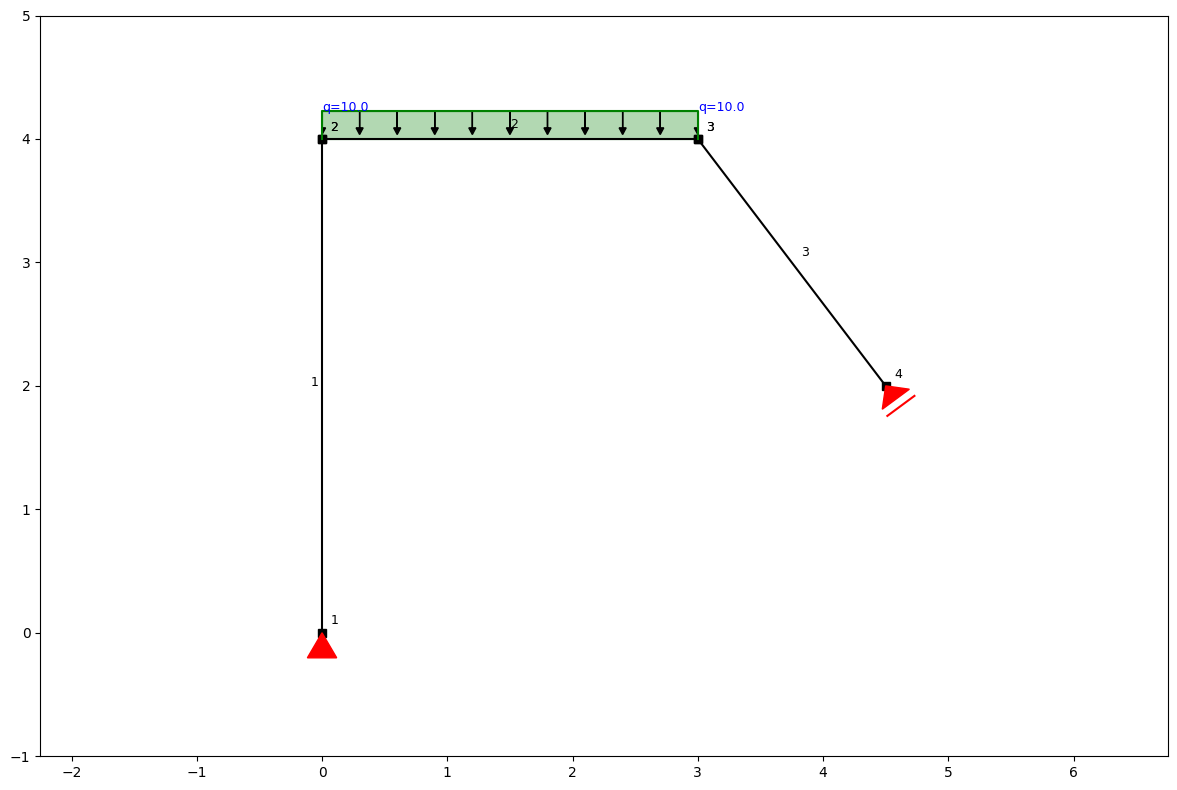

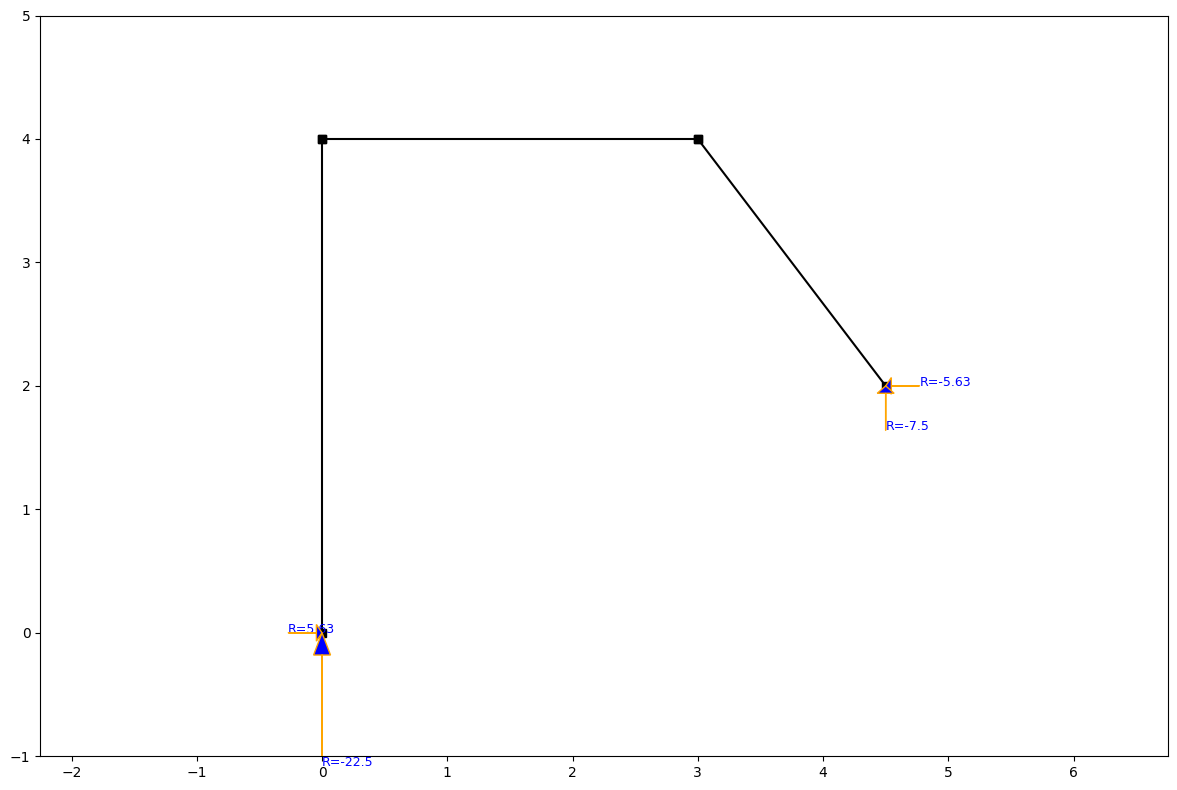

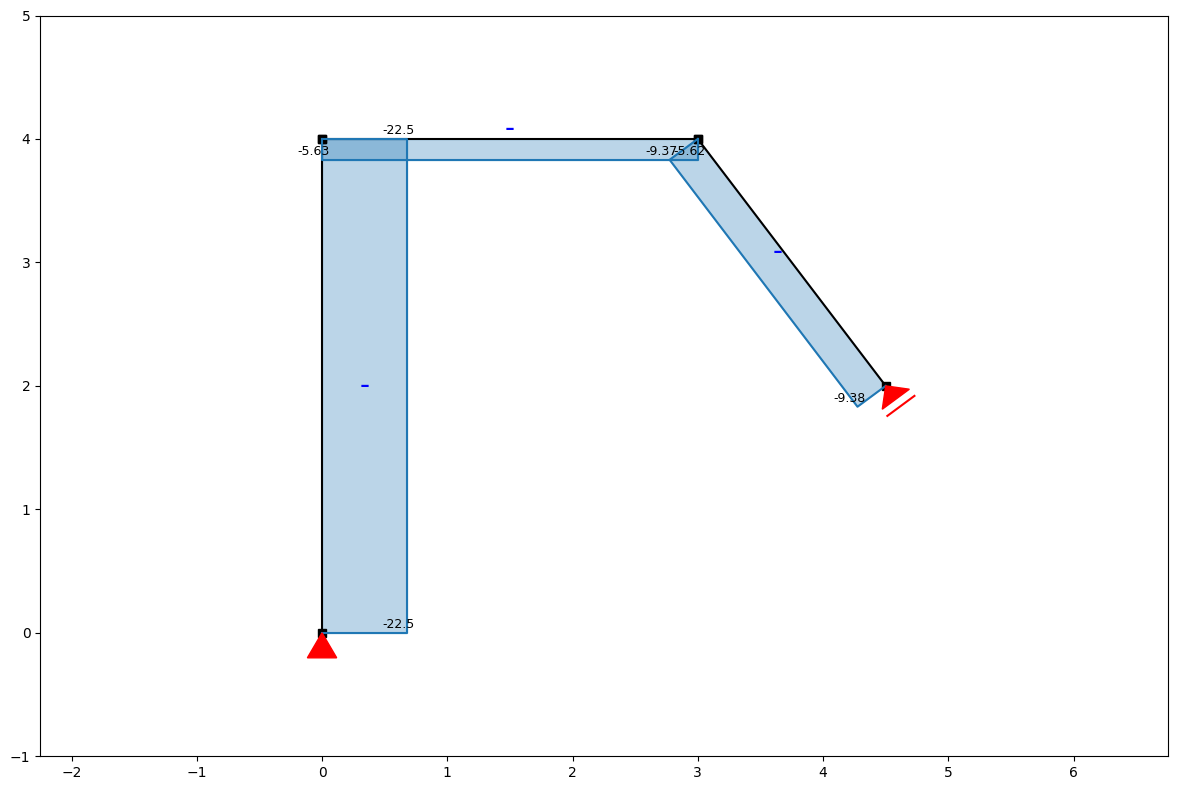

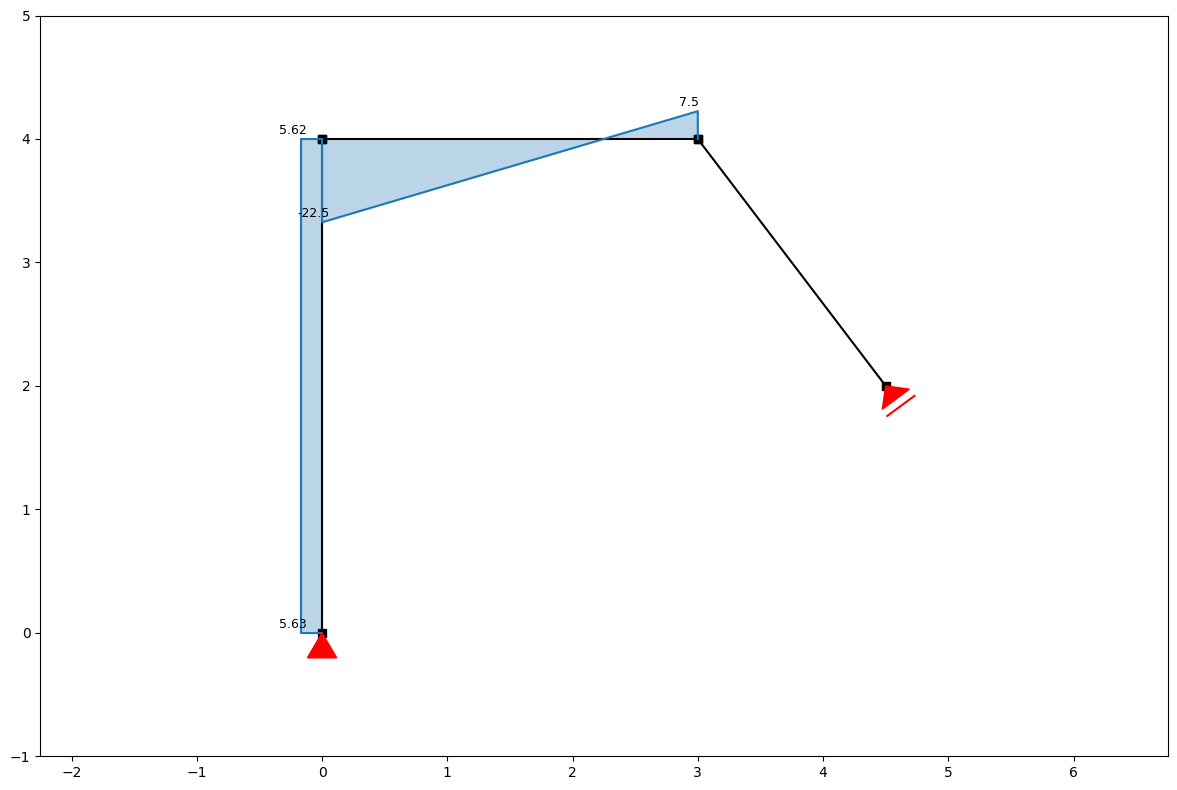

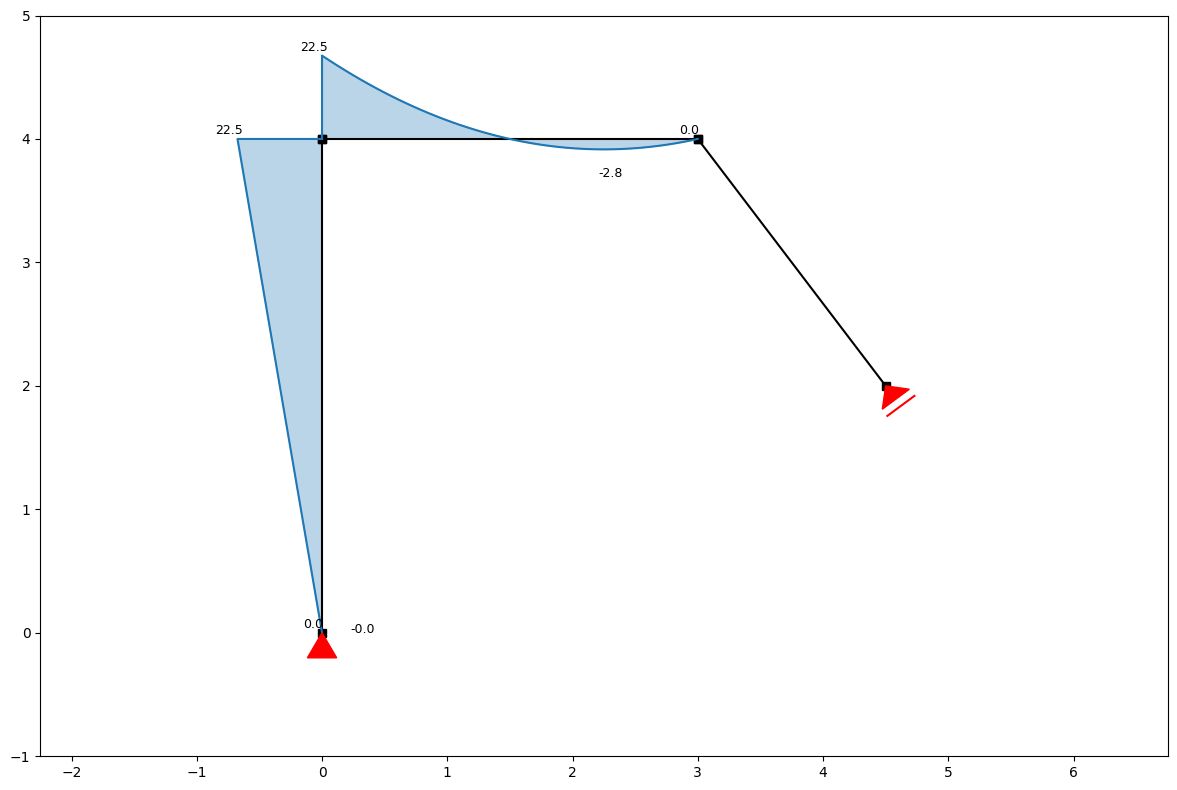

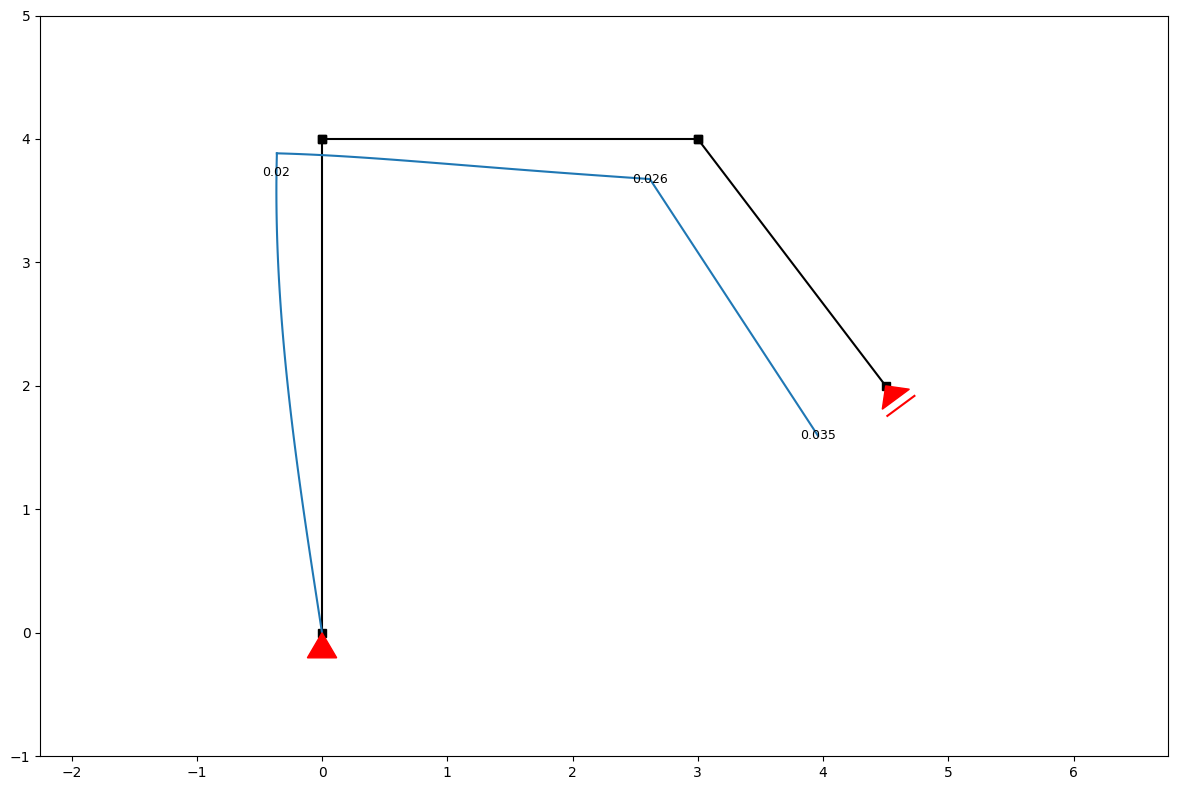

In [ ]:
# SOLUÇÃO EXEMPLO 3

node={
      'A':[0,0],
      'B':[4.5,2],
      'C':[0,4],
      'D':[3,4],
     }

ss = SystemElements()

# Informações dos nós e elementos
ss.add_element(location=[node['A'], node['C'], ])
ss.add_element(location=[node['C'], node['D'], ])
ss.add_element(location=[node['D'], node['B'], ])

# Carregamentos distribuídos
ss.q_load(element_id=2, q=-10, direction='y')

# Apoios
node_id = ss.find_node_id(node['A'])
ss.add_support_hinged(node_id=node_id)
node_id = ss.find_node_id(node['B'])
ss.add_support_roll(node_id=node_id, angle=np.degrees(np.arcsin(3/5)))


ss.solve()
ss.show_structure()
ss.show_reaction_force()
ss.show_axial_force()
ss.show_shear_force()
ss.show_bending_moment()
ss.show_displacement()

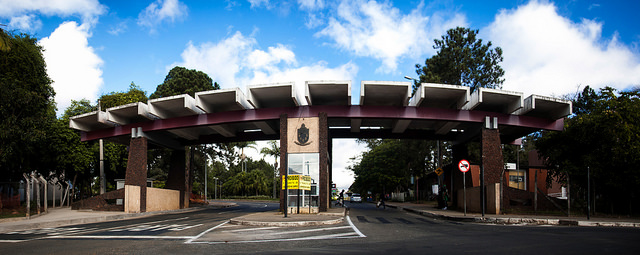

# Exercícios

**Exercício 1:**

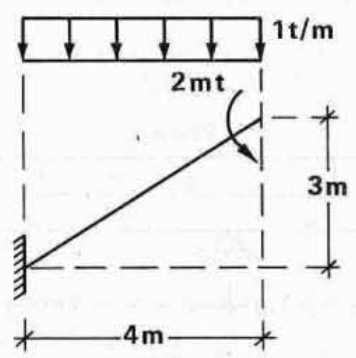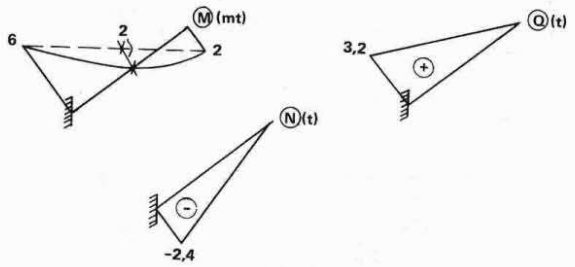

**Exercício 2:**

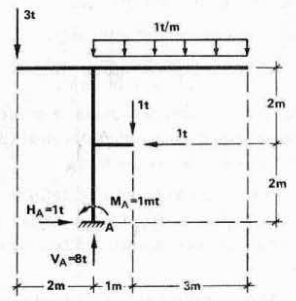

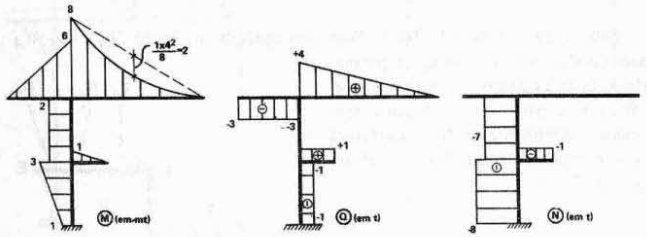

**Exercício 3:**

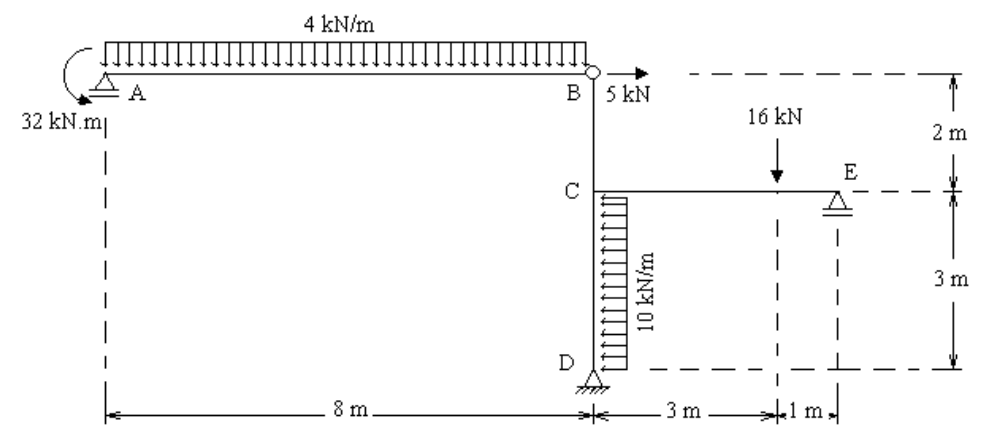

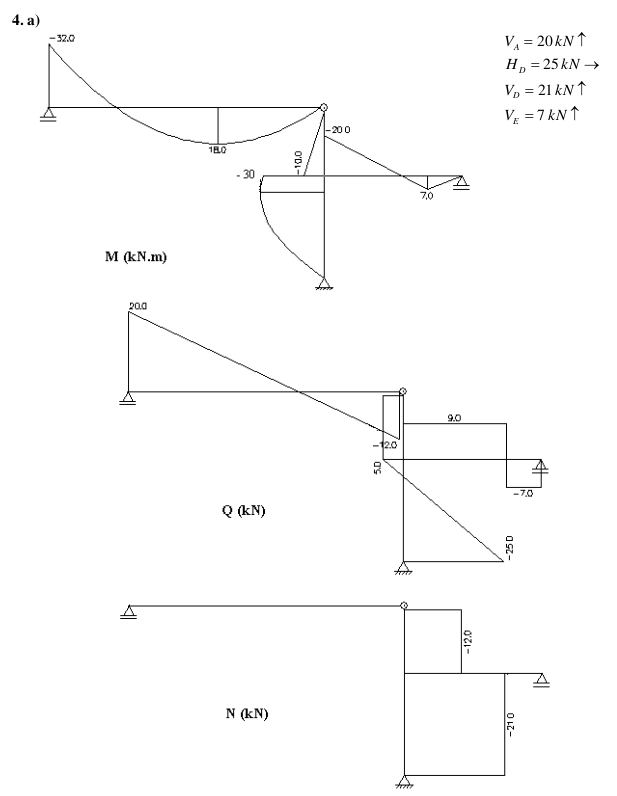

**Exercício 4:** Para adicionar rótula nos dois extremos do mesmo elemento, use "spring={1:0,2:0}".

 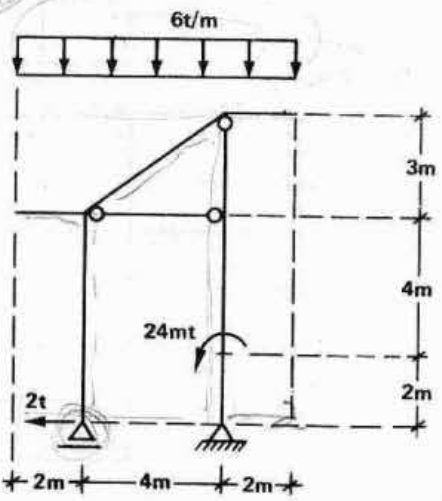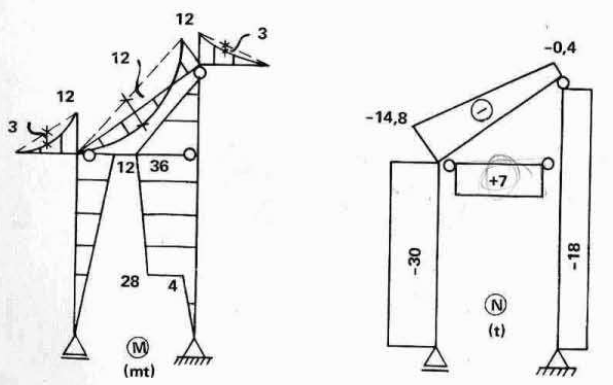